In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Define data paths (using relative paths for GitHub reproducibility)
DATA_DIR = "/content/drive/MyDrive/capstone project"

def load_and_audit_datasets():
    datasets = {
        "customers": "customers.csv",
        "orders": "orders.csv",
        "support_tickets": "support_tickets.csv",
        "web_events": "web_events_snapshot.csv",
        "labels": "churn_labels.csv",
        "interventions": "intervention_history.csv"
    }

    dfs = {}
    print("=== Data Ingestion & Shape Audit ===")
    for name, filename in datasets.items():
        path = os.path.join(DATA_DIR, filename)
        if os.path.exists(path):
            dfs[name] = pd.read_csv(path)
            print(f"✅ Loaded {name:<16} | Rows: {dfs[name].shape[0]:<7} | Columns: {dfs[name].shape[1]}")
        else:
            print(f"❌ Missing critical file: {filename}")
    return dfs

dfs = load_and_audit_datasets()

=== Data Ingestion & Shape Audit ===
✅ Loaded customers        | Rows: 2400    | Columns: 9
✅ Loaded orders           | Rows: 10009   | Columns: 10
✅ Loaded support_tickets  | Rows: 1921    | Columns: 8
✅ Loaded web_events       | Rows: 2400    | Columns: 10
✅ Loaded labels           | Rows: 2400    | Columns: 4
✅ Loaded interventions    | Rows: 2400    | Columns: 5


In [4]:
def check_integrity(dfs):
    print("=== Integrity & Completeness Audit ===\n")
    for name, df in dfs.items():
        missing = df.isnull().sum()
        missing_pct = (missing / len(df)) * 100
        duplicates = df.duplicated().sum()

        print(f"--- {name.upper()} ---")
        print(f"Duplicate Rows: {duplicates}")
        high_missing = missing_pct[missing_pct > 0]
        if not high_missing.empty:
            print("Missing Values:")
            for col, pct in high_missing.items():
                print(f"  • {col}: {missing[col]} ({pct:.2f}%)")
        else:
            print("  • No missing values detected.")
        print()

check_integrity(dfs)

=== Integrity & Completeness Audit ===

--- CUSTOMERS ---
Duplicate Rows: 0
Missing Values:
  • loyalty_tier: 1386 (57.75%)
  • skin_type: 401 (16.71%)

--- ORDERS ---
Duplicate Rows: 0
Missing Values:
  • rating: 80 (0.80%)

--- SUPPORT_TICKETS ---
Duplicate Rows: 0
  • No missing values detected.

--- WEB_EVENTS ---
Duplicate Rows: 0
  • No missing values detected.

--- LABELS ---
Duplicate Rows: 0
  • No missing values detected.

--- INTERVENTIONS ---
Duplicate Rows: 0
  • No missing values detected.



Baseline Brand Churn Rate: 46.96%


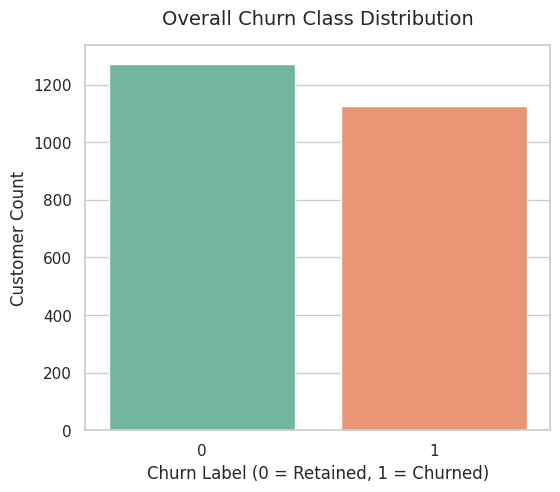

In [10]:
plt.figure(figsize=(6, 5))
sns.countplot(data=dfs["labels"], x="churn_next_60d", hue="churn_next_60d", palette="Set2", legend=False)
plt.title("Overall Churn Class Distribution", fontsize=14, pad=15)
plt.xlabel("Churn Label (0 = Retained, 1 = Churned)")
plt.ylabel("Customer Count")

# Calculate metrics for the markdown report text
churn_rate = dfs["labels"]["churn_next_60d"].mean() * 100
print(f"Baseline Brand Churn Rate: {churn_rate:.2f}%")
plt.savefig("churn_distribution.png", dpi=300, bbox_inches='tight')
plt.show()